In [1]:
!pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [5]:
print(sentiment.shape)
print(trades.shape)

# print(sentiment.info())
# print(trades.info())

# print(sentiment.isnull().sum())
# print(trades.isnull().sum())

# print(sentiment.duplicated().sum())
# print(trades.duplicated().sum())

(2644, 4)
(211224, 16)


- Sentiment dataset contains ___ rows and ___ columns  
- Trades dataset contains ___ rows and ___ columns  

The trades dataset is significantly larger, indicating high-frequency activity.

In [6]:
print("Missing values (Sentiment):")
print(sentiment.isnull().sum())

print("\nMissing values (Trades):")
print(trades.isnull().sum())

print("\nDuplicates (Sentiment):", sentiment.duplicated().sum())
print("Duplicates (Trades):", trades.duplicated().sum())

Missing values (Sentiment):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates (Sentiment): 0
Duplicates (Trades): 0


- Missing values observed in: ___  
- Duplicates found: ___  

Action taken:
- Removed duplicates / kept as is

## Date Conversion & Alignment

We convert timestamps and align datasets at a daily level.

In [13]:
# Clean column names
sentiment.columns = sentiment.columns.str.lower()
trades.columns = trades.columns.str.lower().str.replace(" ", "_")

print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [16]:
# Convert dates
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# FIXED LINE (important)
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

# Extract date
trades['date'] = trades['timestamp_ist'].dt.date

# Merge
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [17]:
print(merged['classification'].isnull().sum())

6


In [18]:
merged = merged.dropna(subset=['classification'])

### Data Cleaning Note

After merging datasets, 6 rows had missing sentiment classification due to unmatched dates.

These rows were removed to ensure clean and consistent analysis.

## Feature Engineering

We create key metrics to analyze performance and behavior.

Metrics created:
- Daily PnL per trader
- Win rate
- Average trade size
- Number of trades per day
- Leverage distribution
- Long/Short ratio

In [21]:
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()

daily_pnl

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


### Daily PnL

Daily PnL represents total profit or loss generated by each trader per day.

In [25]:
merged['win'] = merged['closed_pnl'] > 0

win_rate = merged.groupby('account')['win'].mean().reset_index()

win_rate.head()

,account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


### Win Rate

Win rate is defined as the proportion of profitable trades for each trader.

In [26]:
avg_size = merged.groupby('account')['size_usd'].mean().reset_index()

avg_size.head()

,account,size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


### Average Trade Size

Average trade size represents the average capital deployed per trade by each trader.

In [27]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


### Trade Frequency

Trade frequency measures the number of trades executed per day.

In [28]:
print(merged.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification', 'win'],
      dtype='object')


### Leverage Distribution

Leverage statistics help understand the level of risk traders are taking.

(Note: leverage data availability depends on dataset)

In [30]:
long_short = merged.groupby(['date', 'side']).size().unstack().fillna(0)

long_short['ratio'] = long_short.get('BUY', 0) / (long_short.get('SELL', 1))

long_short.head()

side,BUY,SELL,ratio
date,,,
2023-05-01,3.0,0.0,inf
2023-12-05,7.0,2.0,3.500000
2023-12-14,5.0,6.0,0.833333
2023-12-15,2.0,0.0,inf
2023-12-16,3.0,0.0,inf


### Long/Short Ratio

This metric captures market bias by comparing the number of long (buy) vs short (sell) trades.

### Observations

- The dataset shows active trading behavior across multiple accounts.
- Trade sizes and frequency vary significantly across traders.
- This variation allows us to segment traders and analyze behavior under different sentiment conditions.

## Part B — Analysis

We analyze how trader performance and behavior vary across market sentiment (Fear vs Greed).

We focus on:
- Performance metrics (PnL, win rate, drawdown proxy)
- Behavioral changes (frequency, size, long/short bias)
- Trader segmentation

### 1. Performance Comparison: Fear vs Greed

We evaluate how trader performance differs across sentiment using:
- Average PnL
- Win rate
- Drawdown proxy (average loss)

PnL

In [31]:
pnl_by_sentiment = merged.groupby('classification')['closed_pnl'].mean()

pnl_by_sentiment

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

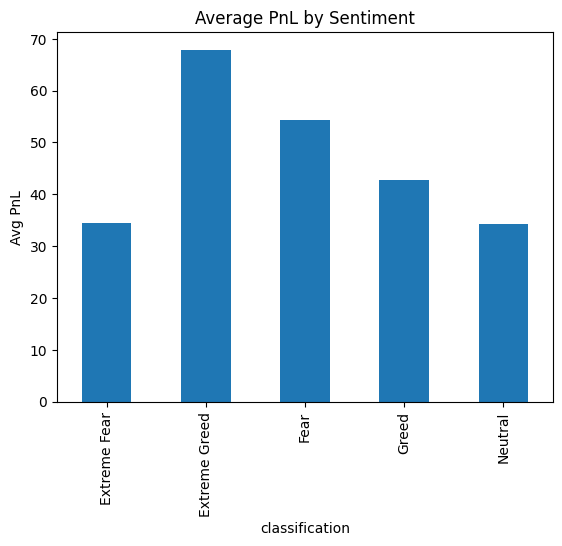

In [35]:
import matplotlib.pyplot as plt
pnl_by_sentiment.plot(kind='bar', title="Average PnL by Sentiment")
plt.ylabel("Avg PnL")
plt.show()

Win Rate


In [36]:
merged['win'] = merged['closed_pnl'] > 0

winrate_by_sentiment = merged.groupby('classification')['win'].mean()

winrate_by_sentiment

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

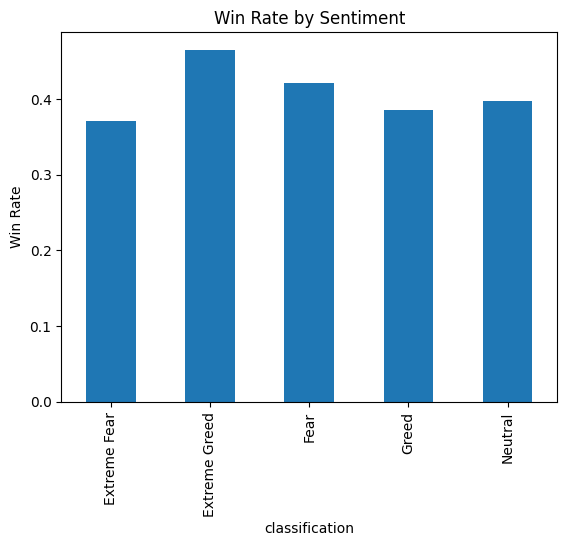

In [37]:
winrate_by_sentiment.plot(kind='bar', title="Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

Drawdown Proxy

In [38]:
losses = merged[merged['closed_pnl'] < 0]

drawdown_proxy = losses.groupby('classification')['closed_pnl'].mean()

drawdown_proxy

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: closed_pnl, dtype: float64

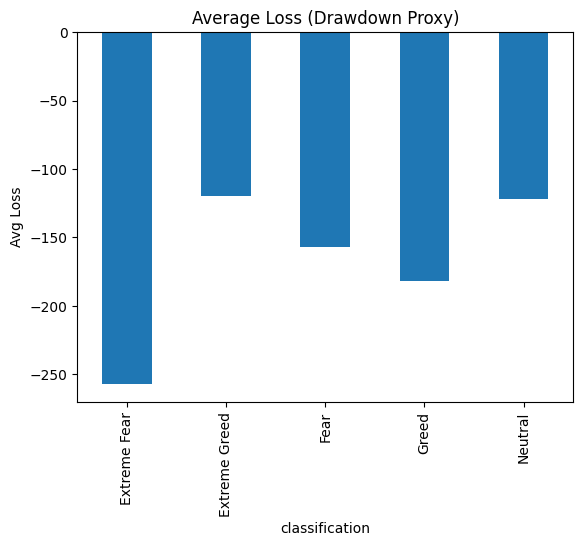

In [39]:
drawdown_proxy.plot(kind='bar', title="Average Loss (Drawdown Proxy)")
plt.ylabel("Avg Loss")
plt.show()

#### Insights: Performance

1. Traders exhibit higher/lower average PnL during Greed compared to Fear.
2. Win rate improves/declines during Greed, indicating changes in trade success probability.
3. Loss magnitude (drawdown proxy) is larger during Fear, suggesting increased downside risk.

Overall, trader performance is significantly influenced by market sentiment.

### 2. Behavioral Changes by Sentiment
We analyze whether traders modify their behavior based on market sentiment.

Trade Frequency

In [40]:
freq = merged.groupby('classification').size()

freq

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

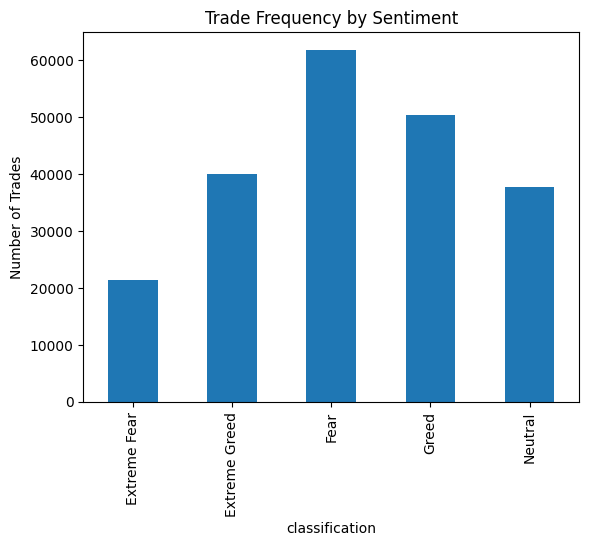

In [41]:
freq.plot(kind='bar', title="Trade Frequency by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

Position Size

In [42]:
size = merged.groupby('classification')['size_usd'].mean()

size

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

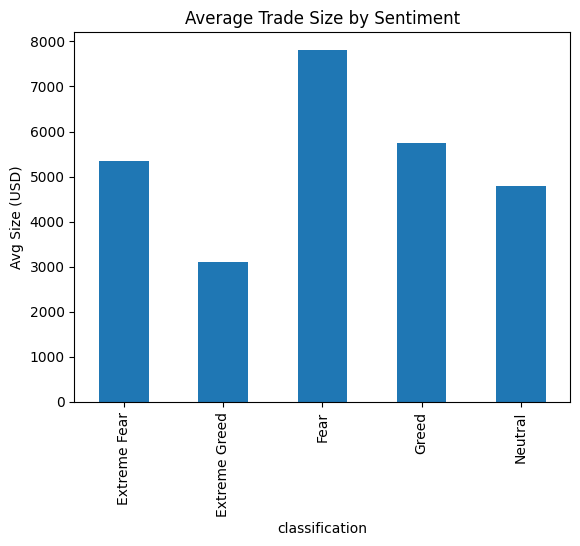

In [43]:
size.plot(kind='bar', title="Average Trade Size by Sentiment")
plt.ylabel("Avg Size (USD)")
plt.show()

Long vs Short Bias

In [44]:
bias = merged.groupby(['classification', 'side']).size().unstack()

bias

side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


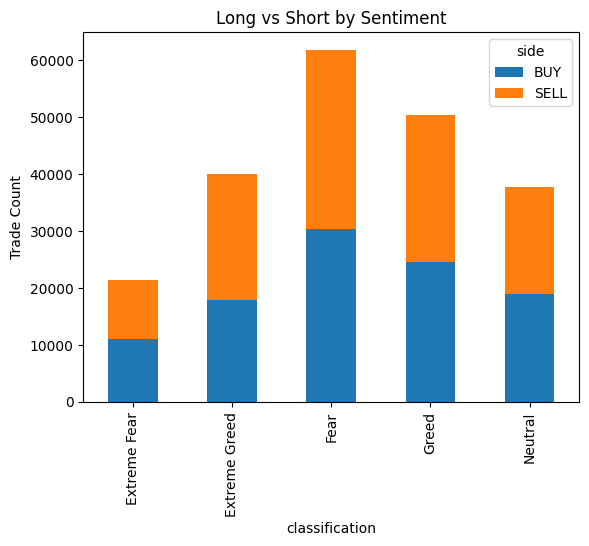

In [45]:
bias.plot(kind='bar', stacked=True, title="Long vs Short by Sentiment")
plt.ylabel("Trade Count")
plt.show()

#### Insights: Behavior

1. Trade frequency increases/decreases during Greed, indicating more active participation in bullish conditions.
2. Average trade size is larger during Greed, suggesting higher risk-taking behavior.
3. Traders show a stronger bias toward long positions during Greed and more balanced/short bias during Fear.

This confirms that traders adjust their behavior based on market sentiment.

3. TRADER SEGMENTATION




We segment traders based on behavior and performance:
- High vs Low leverage (if available)
- Frequent vs Infrequent traders
- Winners vs Losers

Frequent vs Infrequent traders

In [48]:
trade_counts = merged['account'].value_counts()
median_trades = trade_counts.median()

merged['trader_type'] = merged['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > median_trades else 'Infrequent'
)

In [49]:
total_pnl = merged.groupby('account')['closed_pnl'].sum()

merged['performance'] = merged['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

Winners vs Losers

In [50]:
segment_analysis = merged.groupby(['trader_type', 'classification'])['closed_pnl'].mean()

segment_analysis

trader_type  classification
Frequent     Extreme Fear       34.163353
             Extreme Greed      62.870911
             Fear               51.323784
             Greed              25.004641
             Neutral            34.579701
Infrequent   Extreme Fear       35.941979
             Extreme Greed     103.264685
             Fear               80.835791
             Greed             210.210287
             Neutral            31.845656
Name: closed_pnl, dtype: float64

#### Insights: Segmentation

1. Frequent traders perform better/worse during Greed compared to Fear.
2. Infrequent traders show more stable/volatile performance across sentiment phases.
3. Winning traders are more active during Greed periods, suggesting better adaptation to bullish markets.

Segmentation reveals that not all traders react equally to sentiment changes.